# Notebook 5 — Final Forecasting and Evaluation

## Objectives

- **Refit SARIMA** on the **full** monthly demand dataset (2022–2024) per drug.
- **Forecast the next 3 months** (Jan–Mar 2025).
- Save forecasts to `outputs/next_3_month_forecast.csv` with columns: `drug_id`, `forecast_month`, `predicted_demand`.
- Visualize final forecast plots.

## 1. Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX

PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks" and (PROJECT_ROOT.parent / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name != "pharmacy_forecasting":
    PROJECT_ROOT = PROJECT_ROOT / "pharmacy_forecasting"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
DATA_PATH = OUTPUTS_DIR / "monthly_demand.csv"

df = pd.read_csv(DATA_PATH)
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values(["drug_id", "month"]).reset_index(drop=True)

with open(OUTPUTS_DIR / "sarima_orders.json") as f:
    optimal_orders = json.load(f)
for k in optimal_orders:
    optimal_orders[k] = {
        "order": tuple(optimal_orders[k]["order"]),
        "seasonal_order": tuple(optimal_orders[k]["seasonal_order"]),
    }
drug_ids = list(optimal_orders.keys())

## 2. Get Full Series and Refit SARIMA

In [2]:
def get_series(df: pd.DataFrame, drug_id: str) -> pd.Series:
    sub = df[df["drug_id"] == drug_id][["month", "monthly_demand"]].set_index("month").sort_index()
    return sub["monthly_demand"].asfreq("MS").fillna(0)

HORIZON = 3  # Jan, Feb, Mar 2025
final_models = {}
forecasts_next = {}
for drug_id in drug_ids:
    y_full = get_series(df, drug_id)
    order = optimal_orders[drug_id]["order"]
    seasonal_order = optimal_orders[drug_id]["seasonal_order"]
    model = SARIMAX(y_full, order=order, seasonal_order=seasonal_order)
    fitted = model.fit(disp=False)
    final_models[drug_id] = fitted
    forecasts_next[drug_id] = fitted.forecast(steps=HORIZON)
print("Refit on full data and forecasted next 3 months for all drugs.")

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\statsmodels

Refit on full data and forecasted next 3 months for all drugs.


## 3. Build Forecast Table and Save

In [3]:
rows = []
for drug_id in drug_ids:
    fc = forecasts_next[drug_id]
    for t in fc.index:
        rows.append({
            "drug_id": drug_id,
            "forecast_month": t.strftime("%Y-%m-%d") if hasattr(t, "strftime") else str(t),
            "predicted_demand": round(float(fc.loc[t]), 2),
        })
forecast_df = pd.DataFrame(rows)
forecast_df["forecast_month"] = pd.to_datetime(forecast_df["forecast_month"])
out_path = OUTPUTS_DIR / "next_3_month_forecast.csv"
forecast_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
forecast_df

Saved: C:\Users\hp\Desktop\prototype2\pharmacy_forecasting\outputs\next_3_month_forecast.csv


,drug_id,forecast_month,predicted_demand
0,D001,2025-01-01,2754.57
1,D001,2025-02-01,1110.37
2,D001,2025-03-01,917.90
3,D002,2025-01-01,0.00
4,D002,2025-02-01,0.00
5,D002,2025-03-01,0.00
6,D003,2025-01-01,699.25
7,D003,2025-02-01,989.75
8,D003,2025-03-01,746.75
9,D004,2025-01-01,0.00


## 4. Visualize Final Forecasts

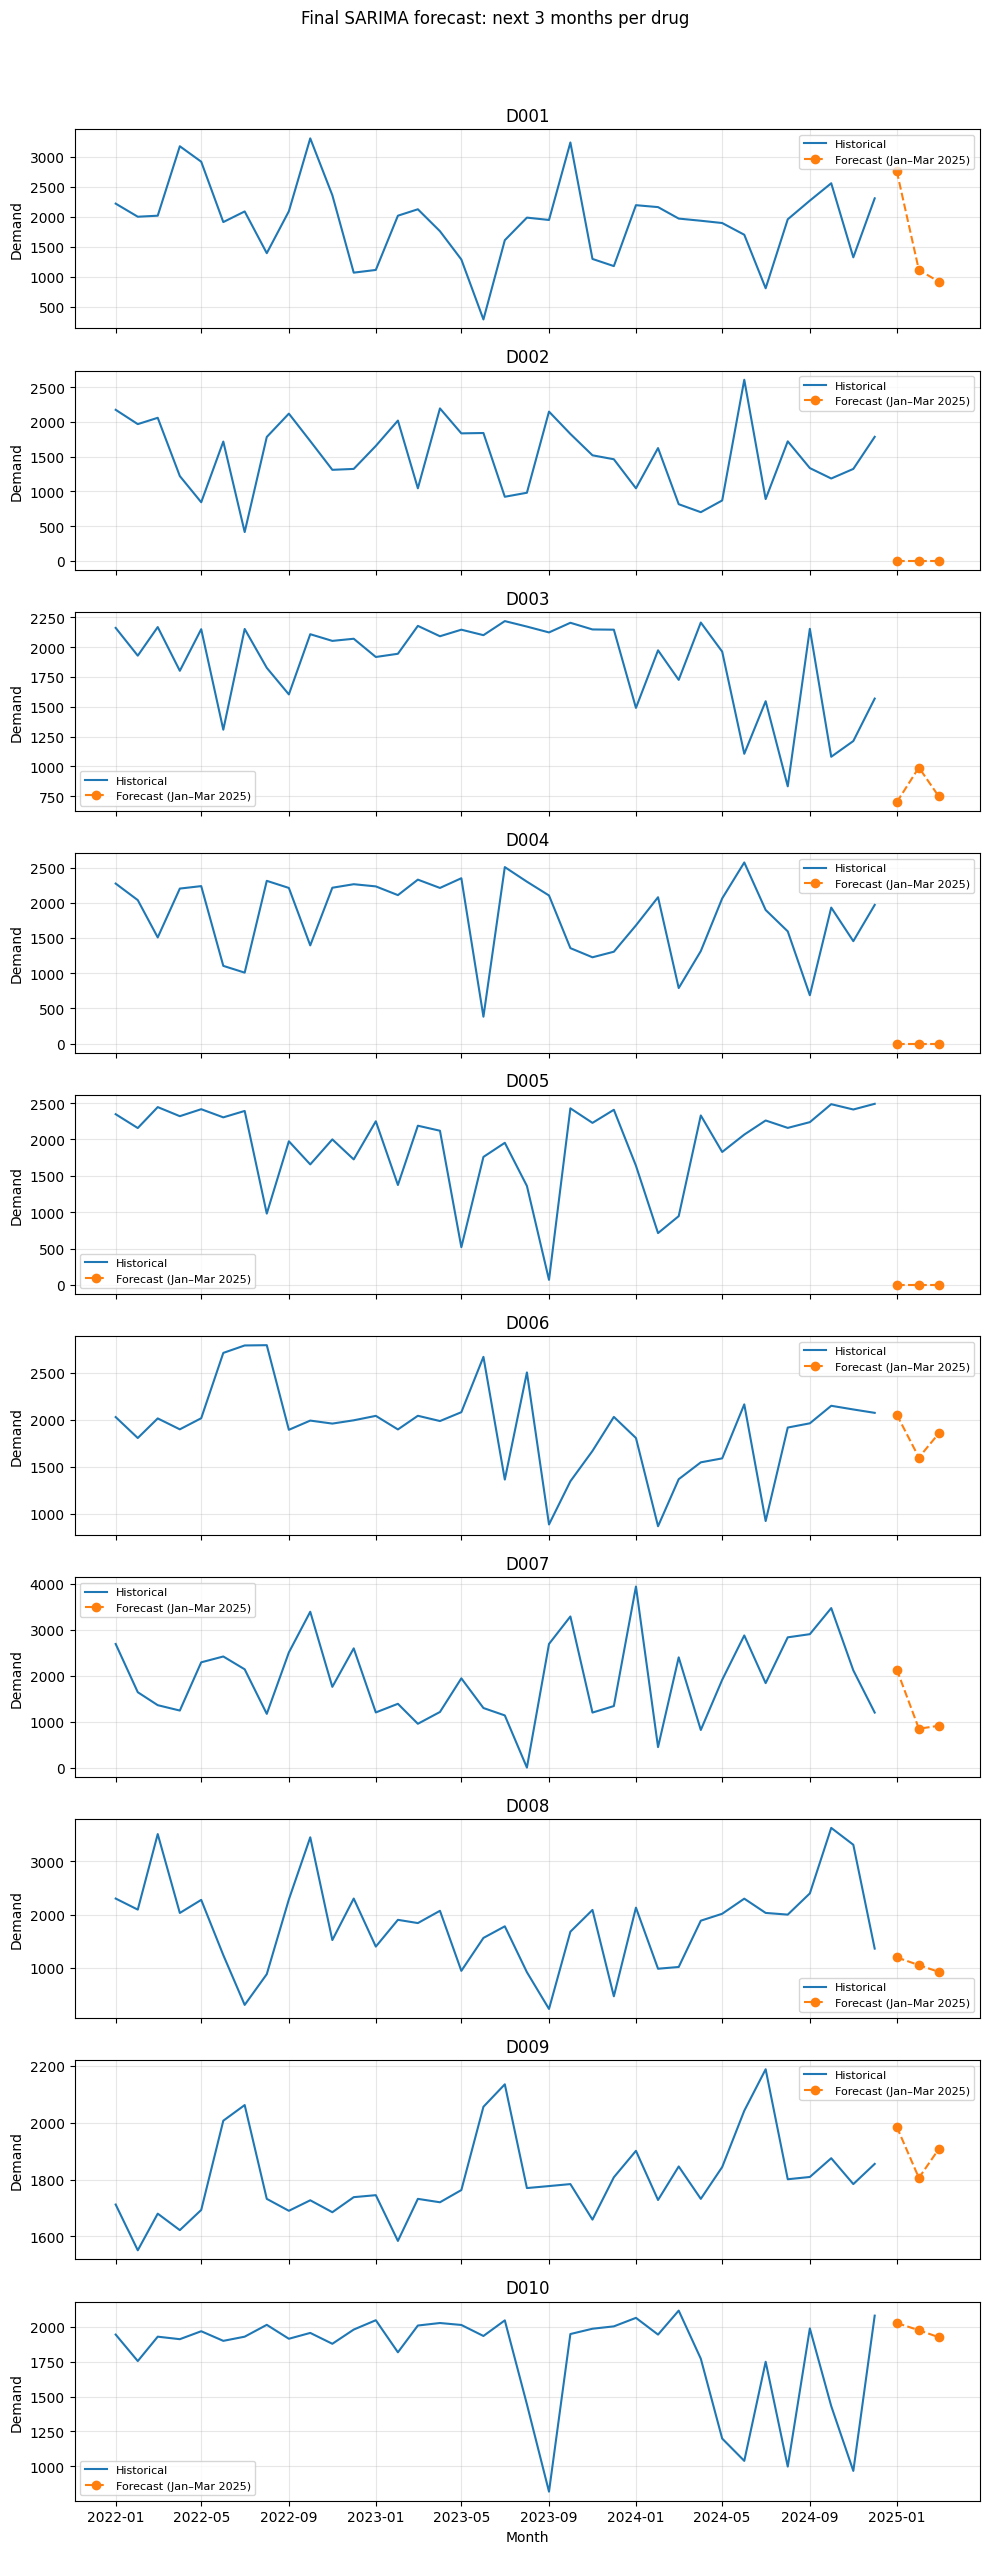

In [4]:
n_drugs = len(drug_ids)
fig, axes = plt.subplots(n_drugs, 1, figsize=(10, 2.5 * n_drugs), sharex=True)
if n_drugs == 1:
    axes = [axes]
for ax, drug_id in zip(axes, drug_ids):
    y_full = get_series(df, drug_id)
    fc = forecasts_next[drug_id]
    ax.plot(y_full.index, y_full.values, label="Historical", color="C0")
    ax.plot(fc.index, fc.values, label="Forecast (Jan–Mar 2025)", color="C1", linestyle="--", marker="o")
    ax.set_ylabel("Demand")
    ax.set_title(f"{drug_id}")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Month")
plt.suptitle("Final SARIMA forecast: next 3 months per drug", y=1.02)
plt.tight_layout()
plt.show()

## 5. Summary

- **Monthly demand** was derived from transaction data (`quantity_dispensed`) in Notebook 1.
- **SARIMA(p,d,q)(P,D,Q,12)** was selected per drug in Notebook 3 and refit on full data here.
- **Next 3 months (Jan–Mar 2025)** forecasts are saved in `outputs/next_3_month_forecast.csv` with columns `drug_id`, `forecast_month`, `predicted_demand`.
- Evaluation metrics and residual diagnostics are in Notebook 4; this notebook produces the final forecast table and plots for submission.